In [4]:
from metab_processing.metab_travlr_config import PROJECT_DATA_DIR, DATA_DIR as METAB_DATA_DIR

DATA_DIR = f'{METAB_DATA_DIR}/GSE208253'
RAW_DATA_DIR = DATA_DIR + '/GSE208253_RAW'

# Load data

In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



SAMPLES = [
    ('6339631', 's1'),
    ('6339632', 's2'),
    ('6339633', 's3'),
    ('6339634', 's4'),
    ('6339635', 's5'),
    ('6339636', 's6'),
    ('6339637', 's7'),
    ('6339638', 's8'),
    ('6339639', 's9'),
    ('6339640', 's10'),
    ('6339641', 's11'),
    ('6339642', 's12'),
]

def load_visium_sample(gsm_id, sample_name):
    adata = sc.read_10x_h5(
        f'{RAW_DATA_DIR}/GSM{gsm_id}_{sample_name}_filtered_feature_bc_matrix.h5'
    )
    adata.var_names_make_unique()  # fix duplicate gene names
    
    positions = pd.read_csv(
        f'{RAW_DATA_DIR}/GSM{gsm_id}_{sample_name}_tissue_positions_list.csv',
        header=None,
        names=['barcode','in_tissue','array_row','array_col','pixel_row','pixel_col']
    )
    positions = positions.drop_duplicates(subset='barcode')
    positions = positions.set_index('barcode')
    
    adata = adata[adata.obs_names.isin(positions[positions['in_tissue']==1].index)]
    adata = adata[~adata.obs_names.duplicated()]
    
    adata.obs = adata.obs.join(positions)
    adata.obsm['spatial'] = adata.obs[['pixel_col','pixel_row']].values
    adata.obs['sample'] = sample_name
    adata.obs_names = [f'{sample_name}_{bc}' for bc in adata.obs_names]
    return adata

# Load and concatenate
adatas = [load_visium_sample(gsm_id, name) for gsm_id, name in SAMPLES]
adata_all = sc.concat(adatas, label='sample', keys=[s[1] for s in SAMPLES])

print(adata_all)
print(adata_all.obs['sample'].value_counts())

In [ ]:
adata_all.write_h5ad(f'{DATA_DIR}/adata.h5ad')
# del adata_all

# SCVI

In [16]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import scvi

In [5]:
adata = sc.read_h5ad(f'{DATA_DIR}/adata.h5ad')
adata

# adata = adata_all

AnnData object with n_obs × n_vars = 26371 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'pixel_row', 'pixel_col', 'sample'
    obsm: 'spatial'

In [ ]:
scvi.model.SCVI.setup_anndata(
    adata,
    batch_key="sample",
)
model = scvi.model.SCVI(adata, n_latent=40)
model

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 40, n_layers: 1, dropout_rate: 0.1, dispersion: gene, gene_likelihood: zinb, 
latent_distribution: normal.
Training status: Not Trained
Model's adata is minified?: False

In [7]:
model.train(accelerator="gpu", devices=1)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.


Epoch 303/303: 100%|██████████| 303/303 [24:06<00:00,  4.85s/it, v_num=1, train_loss=6.38e+3]

`Trainer.fit` stopped: `max_epochs=303` reached.


Epoch 303/303: 100%|██████████| 303/303 [24:06<00:00,  4.77s/it, v_num=1, train_loss=6.38e+3]


In [8]:
model_dir = f'{DATA_DIR}/scvi_model'
model.save(model_dir, overwrite=True)

In [ ]:
# model = scvi.model.SCVI.load(model_dir, adata=adata)

In [9]:
SCVI_LATENT_KEY = "X_scVI"

latent = model.get_latent_representation()
adata.obsm[SCVI_LATENT_KEY] = latent
# np.save('cerebellum_data/scvi_8_latent.npy', latent)
latent.shape

(26371, 40)

/tmp/ipykernel_51834/4056342681.py:2: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=0.5, key_added="leiden_scVI")


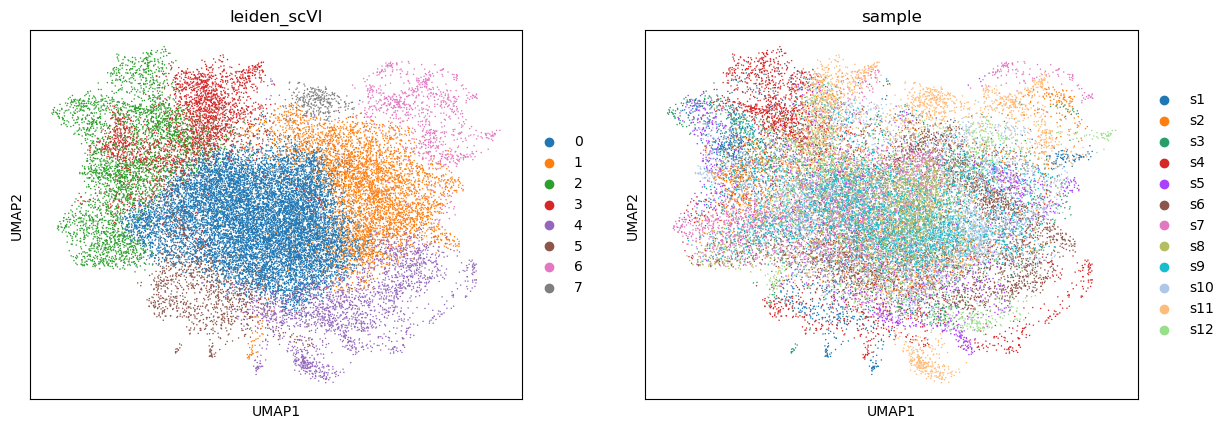

In [17]:
sc.pp.neighbors(adata, use_rep="X_scVI")
sc.tl.leiden(adata, resolution=0.5, key_added="leiden_scVI")
sc.tl.umap(adata)
sc.pl.umap(adata, color=["leiden_scVI", "sample"])

In [18]:
adata.write_h5ad(f'{DATA_DIR}/adata.h5ad')

In [32]:
sc.tl.leiden(adata, resolution=1, key_added="leiden_scVI_1Res")

/tmp/ipykernel_51834/724051964.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=1, key_added="leiden_scVI_1Res")


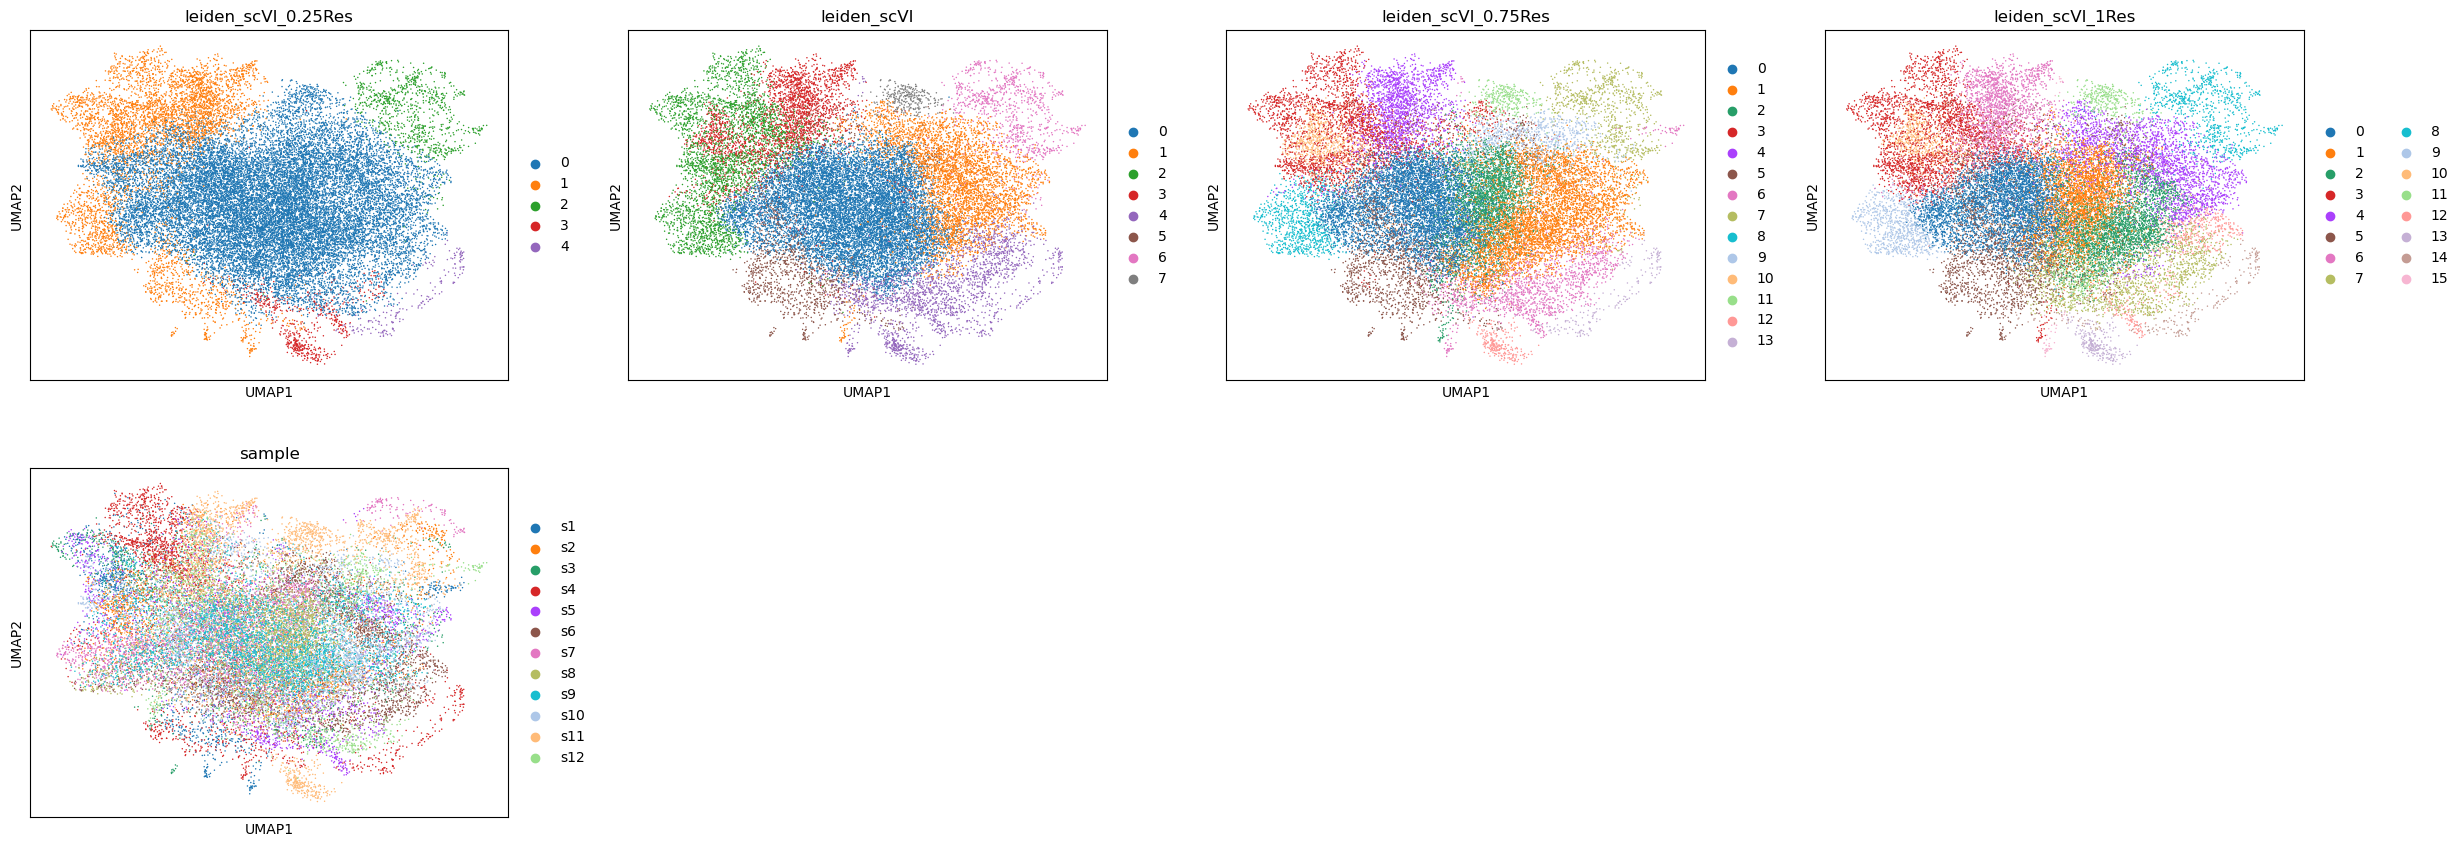

In [41]:
sc.pl.umap(adata, color=["leiden_scVI_0.25Res", "leiden_scVI", "leiden_scVI_0.75Res", "leiden_scVI_1Res", "sample"])

In [23]:
sc.tl.rank_genes_groups(adata, groupby='leiden_scVI', method='wilcoxon')

In [27]:
adata.uns['rank_genes_groups']

{'params': {'groupby': 'leiden_scVI',
  'reference': 'rest',
  'method': 'wilcoxon',
  'use_raw': False,
  'layer': None,
  'corr_method': 'benjamini-hochberg'},
 'names': rec.array([('CXCL10', 'LCE3D', 'TTN', 'IGKC', 'MIR205HG', 'COL1A1', 'SPRR3', 'HSPE1'),
            ('WARS', 'PI3', 'DES', 'IGLC2', 'CXCL14', 'COL3A1', 'KRT13', 'MT1G'),
            ('CXCL9', 'SPRR1B', 'ACTA1', 'IGLC3', 'C10orf99', 'COL1A2', 'S100A14', 'IGHA1'),
            ...,
            ('IGHG4', 'SAA2', 'C19orf33', 'KRT6A', 'CXCL10', 'SPRR1A', 'COL1A1', 'HLA-DRA'),
            ('IGLC2', 'JCHAIN', 'S100A8', 'KRT17', 'APOBEC3A', 'KLK7', 'FN1', 'HLA-DQB1'),
            ('IGKC', 'SAA1', 'TACSTD2', 'KRT16', 'CCL18', 'APOBEC3A', 'POSTN', 'CD74')],
           dtype=[('0', 'O'), ('1', 'O'), ('2', 'O'), ('3', 'O'), ('4', 'O'), ('5', 'O'), ('6', 'O'), ('7', 'O')]),
 'scores': rec.array([( 47.82514 ,  56.872242,  40.413326,  29.295935,  51.016773,  49.30731 ,  40.120537,  28.020214 ),
            ( 41.799267,  55.52686 ,  3

In [28]:
# Get top 15 genes per cluster
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names

for group in groups:
    top_genes = result['names'][group][:15]
    print(f"Cluster {group}: {list(top_genes)}")

Cluster 0: ['CXCL10', 'WARS', 'CXCL9', 'XIST', 'F3', 'CXCL11', 'KRT15', 'GBP1', 'COL22A1', 'MUC1', 'PARP14', 'ISG15', 'XAF1', 'LAMB3', 'RNF213']
Cluster 1: ['LCE3D', 'PI3', 'SPRR1B', 'CNFN', 'CSTA', 'KRTDAP', 'LGALS7B', 'CSTB', 'S100A9', 'SPRR1A', 'IVL', 'SLPI', 'SBSN', 'SPRR2E', 'CRCT1']
Cluster 2: ['TTN', 'DES', 'ACTA1', 'MYL1', 'TNNI1', 'MYH2', 'ACTC1', 'CKM', 'MB', 'TNNT3', 'SLN', 'FHL1', 'TNNC1', 'TNNI2', 'NEB']
Cluster 3: ['IGKC', 'IGLC2', 'IGLC3', 'JCHAIN', 'IGHA1', 'IGLC1', 'IGHG3', 'IGHG2', 'IGHG1', 'IGHD', 'IGHGP', 'MZB1', 'IGHG4', 'WFDC2', 'PIM2']
Cluster 4: ['MIR205HG', 'CXCL14', 'C10orf99', 'GJB2', 'PERP', 'CSTA', 'ITM2B', 'FABP5', 'RPL35A', 'NACA', 'RPS15A', 'RPS24', 'GJB6', 'RPS7', 'S100A8']
Cluster 5: ['COL1A1', 'COL3A1', 'COL1A2', 'SPARC', 'POSTN', 'COL6A3', 'COL6A1', 'LUM', 'COL6A2', 'FN1', 'COL5A1', 'AEBP1', 'DCN', 'COL5A2', 'MMP2']
Cluster 6: ['SPRR3', 'KRT13', 'S100A14', 'CSTB', 'S100A8', 'SPRR2A', 'SERPINB3', 'IL1RN', 'S100A9', 'CSTA', 'CRNN', 'SERPINB4', 'AKR1B10

In [29]:
marker_sets = {
    'Cytotoxic_CD8': ['CD8A', 'CD8B', 'CD3D', 'CD3E', 'GZMB', 'GZMK', 'GZMA', 'PRF1', 'IFNG', 'TNF'],
    'Exhausted_CD8': ['CD8A', 'CD8B', 'CD3D', 'CD3E', 'GZMB', 'GZMK', 'PDCD1', 'LAG3', 'TIGIT', 'HAVCR2', 'CTLA4', 'TOX', 'ENTPD1'],
    'Treg': ['CD4', 'CD3D', 'CD3E', 'FOXP3', 'IL2RA', 'CTLA4', 'IL10', 'TGFB1', 'ENTPD1'],
}

for name, genes in marker_sets.items():
    genes_present = [g for g in genes if g in adata.var_names]
    sc.tl.score_genes(adata, gene_list=genes_present, score_name=f'{name}_score')
    print(f"{name}: using {genes_present}")

# Average score per cluster
score_cols = [f'{name}_score' for name in marker_sets.keys()]
cluster_scores = adata.obs.groupby('leiden_scVI')[score_cols].mean()
print(cluster_scores)

Cytotoxic_CD8: using ['CD8A', 'CD8B', 'CD3D', 'CD3E', 'GZMB', 'GZMK', 'GZMA', 'PRF1', 'IFNG', 'TNF']
Exhausted_CD8: using ['CD8A', 'CD8B', 'CD3D', 'CD3E', 'GZMB', 'GZMK', 'PDCD1', 'LAG3', 'TIGIT', 'HAVCR2', 'CTLA4', 'TOX', 'ENTPD1']
Treg: using ['CD4', 'CD3D', 'CD3E', 'FOXP3', 'IL2RA', 'CTLA4', 'IL10', 'TGFB1', 'ENTPD1']
             Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score
leiden_scVI                                                      
0                       0.027087             0.032151    0.033214
1                      -0.060236            -0.054991   -0.015159
2                      -0.008339             0.000633   -0.002476
3                       0.060993             0.056895    0.043586
4                      -0.144507            -0.140290   -0.130395
5                      -0.051984            -0.037639   -0.018974
6                      -0.047792            -0.051463   -0.033889
7                      -0.142054            -0.137619   -0.145063


/tmp/ipykernel_51834/75394221.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby('leiden_scVI')[score_cols].mean()


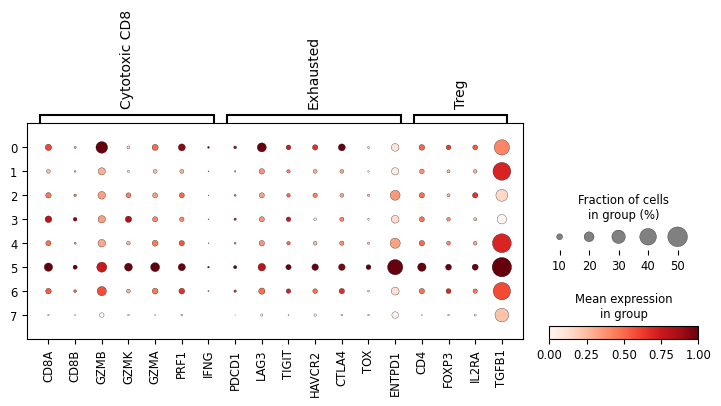

In [30]:
sc.pl.dotplot(
    adata,
    var_names={
        'Cytotoxic CD8': ['CD8A', 'CD8B', 'GZMB', 'GZMK', 'GZMA', 'PRF1', 'IFNG'],
        'Exhausted': ['PDCD1', 'LAG3', 'TIGIT', 'HAVCR2', 'CTLA4', 'TOX', 'ENTPD1'],
        'Treg': ['CD4', 'FOXP3', 'IL2RA', 'TGFB1'],
    },
    groupby='leiden_scVI',
    standard_scale='var'
)

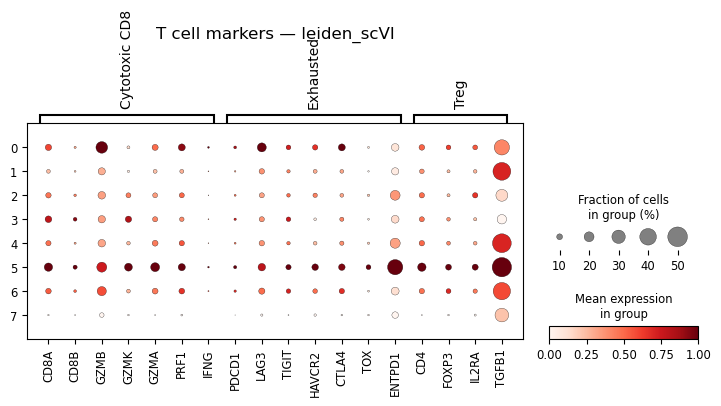

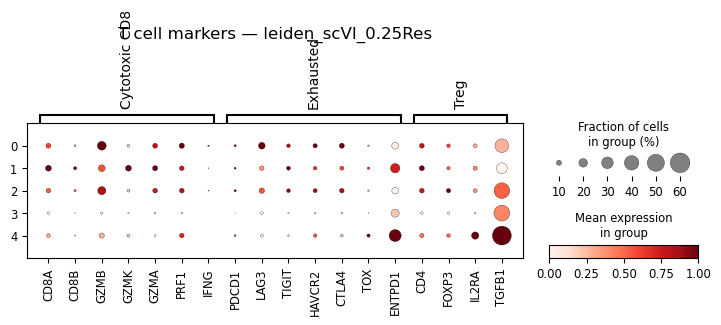

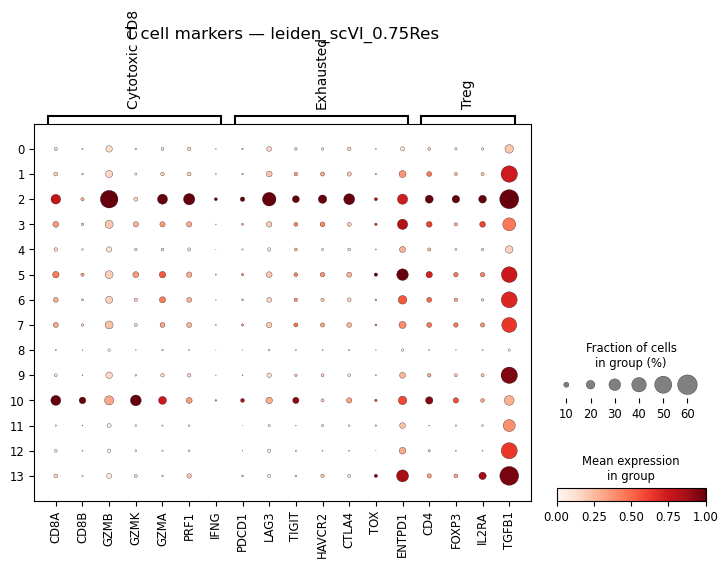

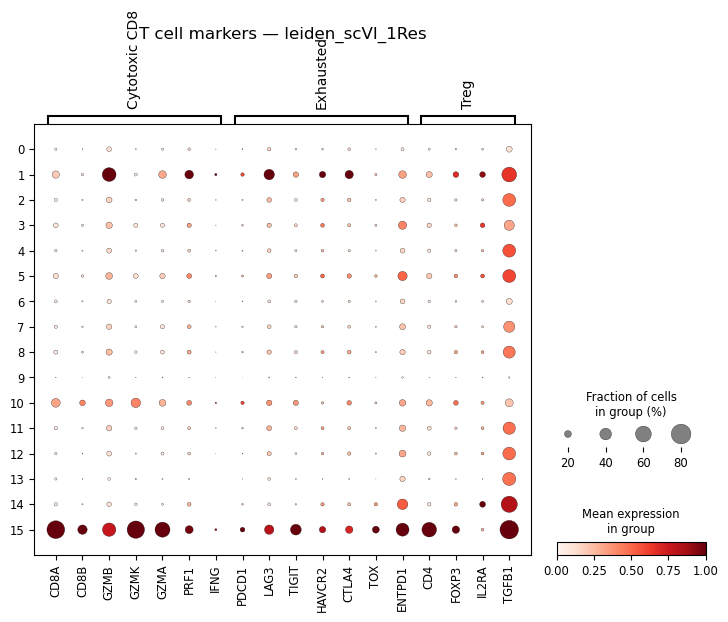

In [35]:
def plot_tcell_markers(adata, groupby_key):
    marker_genes = {
        'Cytotoxic CD8': ['CD8A', 'CD8B', 'GZMB', 'GZMK', 'GZMA', 'PRF1', 'IFNG'],
        'Exhausted': ['PDCD1', 'LAG3', 'TIGIT', 'HAVCR2', 'CTLA4', 'TOX', 'ENTPD1'],
        'Treg': ['CD4', 'FOXP3', 'IL2RA', 'TGFB1'],
    }
    
    # Filter to genes present in adata
    marker_genes_filt = {
        group: [g for g in genes if g in adata.var_names]
        for group, genes in marker_genes.items()
    }
    
    sc.pl.dotplot(
        adata,
        var_names=marker_genes_filt,
        groupby=groupby_key,
        standard_scale='var',
        title=f'T cell markers — {groupby_key}'
    )

# Run for all three resolutions
for res_key in ['leiden_scVI', 'leiden_scVI_0.25Res', 'leiden_scVI_0.75Res', 'leiden_scVI_1Res']:
    plot_tcell_markers(adata, res_key)

In [37]:
# Make sure counts layer exists
if 'counts' not in adata.layers:
    adata.layers['counts'] = adata.X.copy()

# Build log_norm layer from counts if it doesn't exist
if 'log_norm' not in adata.layers:
    adata.X = adata.layers['counts'].copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    adata.layers['log_norm'] = adata.X.copy()
    # Restore raw counts to X
    adata.X = adata.layers['counts'].copy()

print("Layers available:", list(adata.layers.keys()))
print("X max (should be large if raw counts):", adata.X.max())
print("log_norm max (should be small, ~log scale):", adata.layers['log_norm'].max())

/tmp/ipykernel_51834/1663927226.py:8: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(adata, target_sum=1e4)


Layers available: ['counts', 'log_norm']
X max (should be large if raw counts): 10359.0
log_norm max (should be small, ~log scale): 9.210441



RESOLUTION: leiden_scVI_0.25Res

--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['KRT17', 'KRT16', 'KRT14', 'KRT5', 'WARS', 'KRTDAP', 'SFN', 'TMSB10', 'IFI27', 'KRT6B', 'ISG15', 'S100A11', 'GSTP1', 'KRT6A', 'IFI6']
Cluster 1: ['IGKC', 'IGLC2', 'IGLC3', 'IGHG3', 'IGHA1', 'IGHG1', 'IGLC1', 'JCHAIN', 'IGHG4', 'IGHG2', 'TTN', 'MYL1', 'ACTA1', 'MYH2', 'MB']
Cluster 2: ['S100A8', 'CSTB', 'SPRR3', 'S100A9', 'SPRR2A', 'S100A14', 'IL1RN', 'KRT13', 'SERPINB3', 'SPRR1A', 'CSTA', 'SPRR1B', 'CRNN', 'CD24', 'TGM1']
Cluster 3: ['RPL32', 'RPL8', 'RPS18', 'RPS15A', 'MT1G', 'LGALS7', 'RPLP1', 'RPL21', 'RPS8', 'RPS7', 'DSC3', 'RPL29', 'RPS15', 'RPL30', 'RPL34']
Cluster 4: ['DSG1', 'KRT1', 'KRT75', 'KRT10', 'PRSS3', 'KRT2', 'ODC1', 'ID1', 'TPPP3', 'HMGCS1', 'SQLE', 'IGLC7', 'FOS', 'PPP1R14B-AS1', 'MAFB']


/tmp/ipykernel_51834/1384448271.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()



--- Marker set scores per cluster (log_norm) ---
                     Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score
leiden_scVI_0.25Res                                                      
0                              -0.003845             0.001003    0.010317
1                               0.015093             0.017163    0.014200
2                              -0.033814            -0.032725   -0.014086
3                              -0.103992            -0.095400   -0.076619
4                              -0.108421            -0.101886   -0.096946


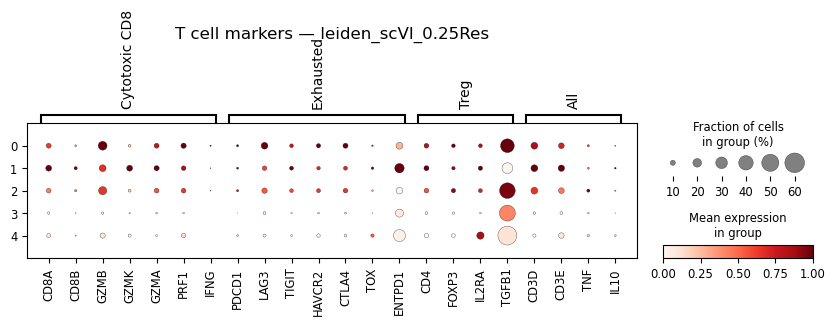


RESOLUTION: leiden_scVI

--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['WARS', 'HLA-B', 'CXCL10', 'TMSB10', 'ISG15', 'HLA-A', 'TYMP', 'IFI6', 'LY6E', 'ACTB', 'LAMB3', 'PSME2', 'IFITM3', 'STAT2', 'HLA-C']
Cluster 1: ['S100A9', 'SPRR1B', 'S100A8', 'PI3', 'KRT6B', 'KRT6A', 'CSTB', 'KRTDAP', 'KRT17', 'CNFN', 'CSTA', 'SLPI', 'KRT16', 'LCE3D', 'SBSN']
Cluster 2: ['TTN', 'MT-CO3', 'DES', 'ACTA1', 'MT-ND4', 'MYL1', 'TNNI1', 'MT-ND1', 'ACTC1', 'TNNT3', 'MYH2', 'CKM', 'MT-ATP6', 'MB', 'IGFBP4']
Cluster 3: ['IGKC', 'IGHA1', 'IGLC2', 'IGLC3', 'IGHG3', 'IGLC1', 'IGHG1', 'JCHAIN', 'IGHG2', 'IGHG4', 'RPL32', 'RPLP1', 'RPS12', 'FTL', 'TMSB4X']
Cluster 4: ['C10orf99', 'DSG1', 'GJB2', 'CXCL14', 'PERP', 'GJB6', 'FABP5', 'UPK3BL1', 'HOPX', 'DSC3', 'S100A8', 'CSTA', 'TMEM45A', 'GPNMB', 'DSG3']
Cluster 5: ['COL1A1', 'COL1A2', 'COL3A1', 'SPARC', 'COL6A1', 'COL6A3', 'POSTN', 'COL6A2', 'LUM', 'COL5A1', 'COL5A2', 'FN1', 'MMP2', 'DCN', 'HTRA1']
Cluster 6: ['S100A8', 'S100A14', 'SPRR3', 'CSTB', 'KRT13'

/tmp/ipykernel_51834/1384448271.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()



--- Marker set scores per cluster (log_norm) ---
             Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score
leiden_scVI                                                      
0                       0.015265             0.021000    0.026441
1                      -0.036792            -0.032286   -0.009379
2                      -0.008698            -0.001164    0.001398
3                       0.060078             0.055515    0.044813
4                      -0.071338            -0.070730   -0.057500
5                      -0.026073            -0.017640   -0.006693
6                      -0.035324            -0.034851   -0.021641
7                      -0.093428            -0.086909   -0.082200


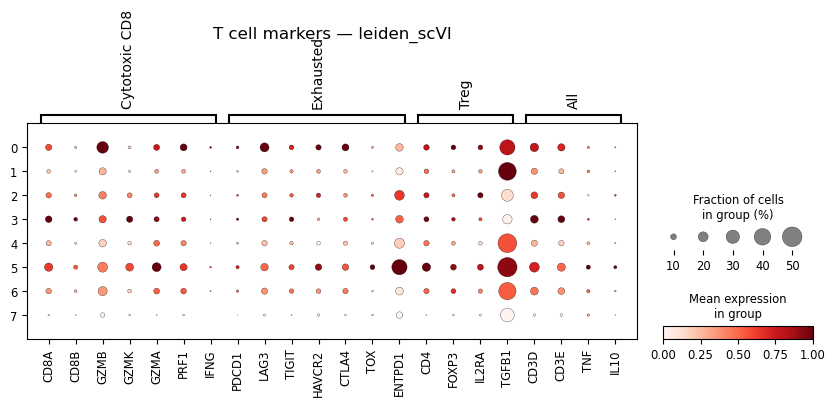


RESOLUTION: leiden_scVI_0.75Res

--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['HLA-B', 'ACTB', 'HLA-A', 'MIR205HG', 'WARS', 'MALAT1', 'TYMP', 'CXCL10', 'TMSB10', 'IFI6', 'CD74', 'B2M', 'RPL17', 'FN1', 'ISG15']
Cluster 1: ['KRT6A', 'KRT6B', 'LGALS7B', 'KRT6C', 'KRT16', 'KRT14', 'LY6D', 'LYPD3', 'GSTP1', 'SFN', 'FABP5', 'SPRR1B', 'KRT5', 'KRTDAP', 'IVL']
Cluster 2: ['CXCL10', 'HLA-A', 'LY6E', 'HLA-B', 'KRT15', 'ISG15', 'SAA1', 'HLA-C', 'F3', 'IGFBP3', 'MUC1', 'FXYD5', 'IFI6', 'HLA-DRB1', 'LGALS3BP']
Cluster 3: ['MT-ND4', 'MT-ND1', 'MT-ND3', 'DES', 'MT-ATP6', 'TTN', 'ACTA1', 'MT-CYB', 'MT-CO3', 'TNNT3', 'TNNI1', 'ACTC1', 'MYL1', 'CKM', 'MT-ND2']
Cluster 4: ['IGKC', 'IGHA1', 'IGLC2', 'IGLC3', 'IGHG3', 'IGLC1', 'IGHG1', 'JCHAIN', 'IGHG2', 'IGHG4', 'SSR4', 'IGHGP', 'MZB1', 'IGHD', 'RPLP1']
Cluster 5: ['COL1A1', 'COL3A1', 'COL1A2', 'SPARC', 'COL6A3', 'COL6A1', 'POSTN', 'LUM', 'COL6A2', 'COL5A2', 'FN1', 'DCN', 'COL5A1', 'AEBP1', 'IGFBP7']
Cluster 6: ['GJB2', 'CXCL14', 'GJB6', 'C10o

/tmp/ipykernel_51834/1384448271.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()



--- Marker set scores per cluster (log_norm) ---
                     Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score
leiden_scVI_0.75Res                                                      
0                               0.010474             0.015737    0.018503
1                              -0.036262            -0.027781   -0.004419
2                               0.054480             0.057769    0.054308
3                              -0.011807            -0.004018    0.001637
4                              -0.002590             0.004371    0.006302
5                              -0.022948            -0.016070   -0.003211
6                              -0.063195            -0.065981   -0.052219
7                              -0.034864            -0.033412   -0.021447
8                              -0.002122             0.003445   -0.001596
9                              -0.035861            -0.034840   -0.004909
10                              0.200090             0.169759 

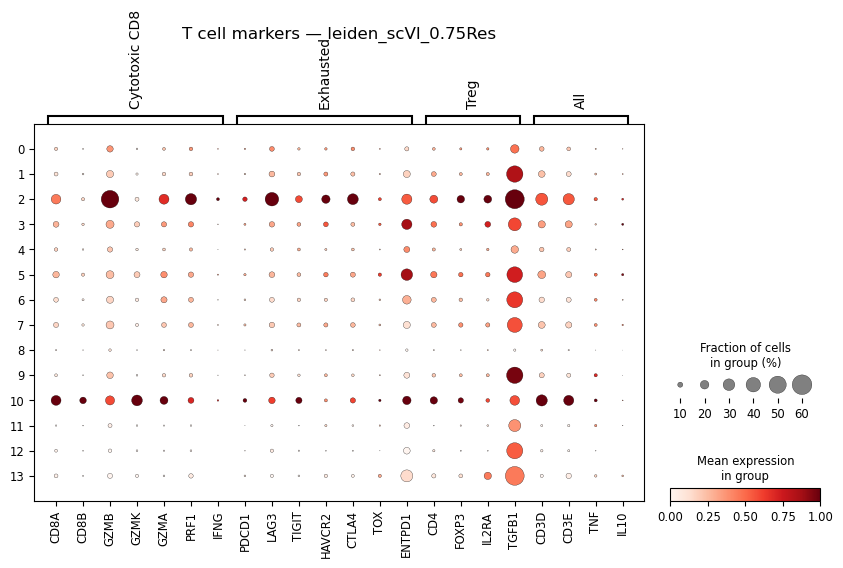


RESOLUTION: leiden_scVI_1Res

--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['HLA-B', 'ACTB', 'MALAT1', 'HLA-A', 'MIR205HG', 'WARS', 'TYMP', 'FN1', 'B2M', 'CD74', 'IFI6', 'RPL17', 'CXCL10', 'TMSB10', 'ITM2B']
Cluster 1: ['CXCL10', 'LY6E', 'HLA-A', 'HLA-B', 'ISG15', 'HLA-C', 'KRT15', 'MUC1', 'SAA1', 'LGALS3BP', 'HLA-DRB1', 'IFI6', 'FXYD5', 'TYMP', 'F3']
Cluster 2: ['KRT14', 'KRT6A', 'LGALS7B', 'KRT6B', 'KRT5', 'GSTP1', 'KRT6C', 'SFN', 'LY6D', 'LYPD3', 'FABP5', 'KRT16', 'S100A11', 'IFI27', 'CSRP2']
Cluster 3: ['DES', 'TTN', 'ACTA1', 'MT-ND1', 'MT-ND3', 'MT-ND4', 'IGFBP4', 'TNNT3', 'MT-ATP6', 'TNNI1', 'MT-CYB', 'NNMT', 'MT-CO3', 'ACTC1', 'CKM']
Cluster 4: ['S100A9', 'S100A8', 'SPRR1B', 'S100A7', 'CNFN', 'PI3', 'SLPI', 'SBSN', 'KRT17', 'CSTB', 'LCE3D', 'SPRR2E', 'CRCT1', 'SPRR1A', 'KRTDAP']
Cluster 5: ['COL1A1', 'COL3A1', 'COL1A2', 'SPARC', 'COL6A3', 'COL6A1', 'LUM', 'POSTN', 'COL6A2', 'FN1', 'COL5A2', 'IGFBP7', 'COL5A1', 'DCN', 'AEBP1']
Cluster 6: ['IGKC', 'IGHA1', 'IGLC2', 'IGL

/tmp/ipykernel_51834/1384448271.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()



--- Marker set scores per cluster (log_norm) ---
                  Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score
leiden_scVI_1Res                                                      
0                            0.011663             0.017021    0.018305
1                            0.054842             0.058701    0.055468
2                           -0.031041            -0.021505    0.001441
3                           -0.010579            -0.001986    0.002328
4                           -0.034076            -0.031692   -0.003960
5                           -0.018713            -0.011740    0.002848
6                           -0.002425             0.005976    0.006729
7                           -0.056836            -0.059321   -0.047570
8                           -0.034932            -0.033828   -0.020794
9                           -0.002112             0.001022   -0.002898
10                           0.230242             0.191320    0.148863
11                         

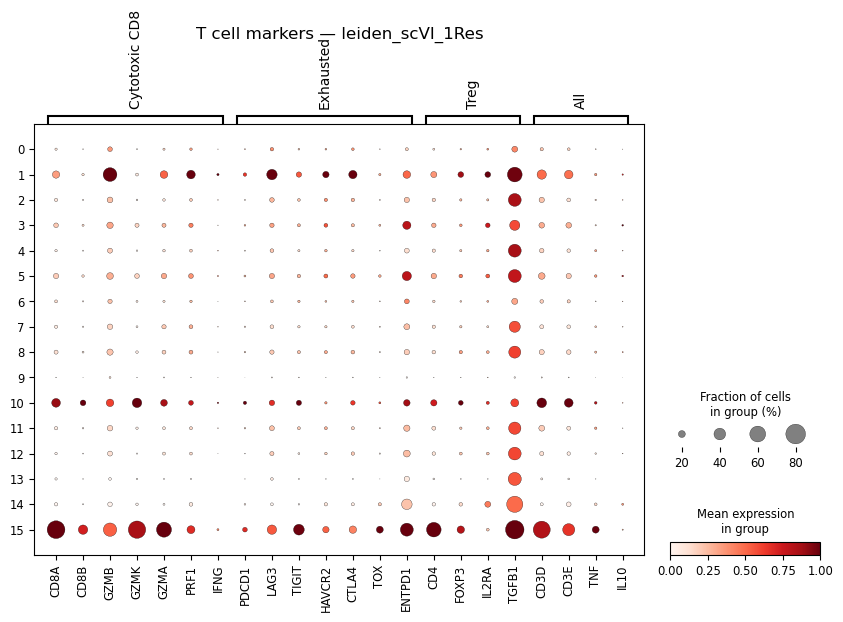

In [ ]:
marker_sets = {
    'Cytotoxic_CD8': ['CD8A', 'CD8B', 'CD3D', 'CD3E', 'GZMB', 'GZMK', 'GZMA', 'PRF1', 'IFNG', 'TNF'],
    'Exhausted_CD8': ['CD8A', 'CD8B', 'CD3D', 'CD3E', 'GZMB', 'GZMK', 'PDCD1', 'LAG3', 'TIGIT', 'HAVCR2', 'CTLA4', 'TOX', 'ENTPD1'],
    'Treg': ['CD4', 'CD3D', 'CD3E', 'FOXP3', 'IL2RA', 'CTLA4', 'IL10', 'TGFB1', 'ENTPD1'],
}

marker_genes_dotplot = {
    'Cytotoxic CD8': ['CD8A', 'CD8B', 'GZMB', 'GZMK', 'GZMA', 'PRF1', 'IFNG'],
    'Exhausted': ['PDCD1', 'LAG3', 'TIGIT', 'HAVCR2', 'CTLA4', 'TOX', 'ENTPD1'],
    'Treg': ['CD4', 'FOXP3', 'IL2RA', 'TGFB1'],
    'All': ['CD3D', 'CD3E', 'TNF', 'IL10'],
}


def annotate_clusters(adata, groupby_key, n_top_genes=15):
    print(f"\n{'='*60}")
    print(f"RESOLUTION: {groupby_key}")
    print(f"{'='*60}")
    
    # --- Approach 1: top DE genes per cluster (on log_norm) ---
    sc.tl.rank_genes_groups(
        adata,
        groupby=groupby_key,
        method='wilcoxon',
        layer='log_norm',
        use_raw=False
    )
    result = adata.uns['rank_genes_groups']
    groups = result['names'].dtype.names
    
    print("\n--- Top DE genes per cluster (log_norm) ---")
    for group in groups:
        top_genes = result['names'][group][:n_top_genes]
        print(f"Cluster {group}: {list(top_genes)}")
    
    # --- Approach 2: marker set scores per cluster (on log_norm) ---
    for name, genes in marker_sets.items():
        genes_present = [g for g in genes if g in adata.var_names]
        sc.tl.score_genes(
            adata,
            gene_list=genes_present,
            score_name=f'{name}_score',
            layer='log_norm'
        )
    
    score_cols = [f'{name}_score' for name in marker_sets.keys()]
    cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
    print("\n--- Marker set scores per cluster (log_norm) ---")
    print(cluster_scores)
    
    # --- Approach 3: dot plot (on log_norm) ---
    marker_genes_filt = {
        group: [g for g in genes if g in adata.var_names]
        for group, genes in marker_genes_dotplot.items()
    }
    sc.pl.dotplot(
        adata,
        var_names=marker_genes_filt,
        groupby=groupby_key,
        layer='log_norm',
        standard_scale='var',
        title=f'T cell markers — {groupby_key}'
    )
    
    return cluster_scores


# Run for all three resolutions
all_scores = {}
for res_key in ['leiden_scVI_0.25Res', 'leiden_scVI', 'leiden_scVI_0.75Res', 'leiden_scVI_1Res']:
    all_scores[res_key] = annotate_clusters(adata, res_key)

In [40]:
adata.write_h5ad(f'{DATA_DIR}/adata_minus_annot.h5ad')